This project is following the guidance of 'Overview.md'

# Step 1. Data Layer
    - Movie dataset: use public datasets

    - User profiles:  name, age, preferences, watch_history
        Example:
        {
            "name": "John",
            "age": 25,
            "preferences": ["action", "thriller"],
            "watch_history": [{"movie": "Inception", "genre": "sci-fi", "rating": 5}]
        }
        create a user profile simulator

    - Storage: save data to json / csv file

In [2]:
import sys
import os
sys.path.insert(0, os.path.abspath(".."))  # make src/ importable

from src.data_simulation import load_movielens, simulate_user_profiles, save_user_profiles, load_user_profiles

# Load MovieLens dataset
movies, ratings, tags = load_movielens()


Dataset already exists, skipping download.
Movies:  9,742 rows
Ratings: 100,836 rows
Tags:    3,683 rows


In [3]:
# Preview the data
import pandas as pd

print("=== movies.csv ===")
display(movies.head())

print("\n=== ratings.csv ===")
display(ratings.head())

print("\n=== tags.csv ===")
display(tags.head())


=== movies.csv ===


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



=== ratings.csv ===


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931



=== tags.csv ===


,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


In [4]:
# Basic stats
print("Rating scale:", ratings["rating"].min(), "–", ratings["rating"].max())
print("Unique users:", ratings["userId"].nunique())
print("Unique movies rated:", ratings["movieId"].nunique())
print("\nTop genres:")
movies["genres"].str.split("|").explode().value_counts().head(10)


Rating scale: 0.5 – 5.0
Unique users: 610
Unique movies rated: 9724

Top genres:


genres
Drama        4361
Comedy       3756
Thriller     1894
Action       1828
Romance      1596
Adventure    1263
Crime        1199
Sci-Fi        980
Horror        978
Fantasy       779
Name: count, dtype: int64

## Simulated User Profiles
Synthetic users with realistic noise:
- Each user has 1–3 preferred genres but occasionally watches outside them
- Ratings are noisy (same genre doesn't always get the same score) 
    -- preferred genre get 4 + noise
    -- other genre 2.8 + noise
- Watch history length varies 
    -- 65% power users watch 30-60 movies,
    -- 25% casual viewers watch 5-15 movies
    -- 10% cold starter empty movie list
- A few cold-start users with no history
- Age influences genre affinity slightly
    -- each user has 1-3 preferred genres
    -- choose from biased_genre_pool = age_genre_biased + 2 random genres

In [5]:
# Simulate and save user profiles
user_profiles = simulate_user_profiles(movies)

print(f"Generated {len(user_profiles)} user profiles")
print(f"  Cold-start users (no history): {sum(1 for u in user_profiles if not u['watch_history'])}")

import numpy as np
print(f"  Avg watch history length: {np.mean([len(u['watch_history']) for u in user_profiles]):.1f} movies")


Generated 20 user profiles
  Cold-start users (no history): 1
  Avg watch history length: 18.9 movies


In [6]:
# Inspect a few profiles
for u in user_profiles[:3]:
    print(f"[User {u['user_id']}] {u['name']}, age {u['age']}")
    print(f"  Preferred genres : {u['preferred_genres']}")
    print(f"  Watch history    : {len(u['watch_history'])} movies")
    if u["watch_history"]:
        for m in u["watch_history"][:3]:
            print(f"    • {m['title']} ({m['genre_watched']}) → rated {m['rating']}")
    else:
        print("    • (cold-start — no history)")
    print()


[User 1] Danielle, age 28
  Preferred genres : ['Horror', 'Sci-Fi', 'Comedy']
  Watch history    : 32 movies
    • Cyrano de Bergerac (1990) (Comedy) → rated 4.5
    • Thinner (1996) (Horror) → rated 4.0
    • Sisters (1973) (Horror) → rated 4.5

[User 2] Angel, age 62
  Preferred genres : ['Drama']
  Watch history    : 14 movies
    • Hard Candy (2005) (Drama) → rated 3.5
    • The Great Hypnotist (2014) (Drama) → rated 4.5
    • 8MM (1999) (Drama) → rated 3.0

[User 3] Joshua, age 45
  Preferred genres : ['Drama']
  Watch history    : 9 movies
    • Jackie Brown (1997) (Drama) → rated 4.5
    • Inventing the Abbotts (1997) (Drama) → rated 4.0
    • Drugstore Cowboy (1989) (Crime) → rated 1.5



In [7]:
# Save profiles to data/ and preview the flat ratings CSV
user_ratings_df = save_user_profiles(user_profiles)
display(user_ratings_df.head(8))


Saved /Users/jingjingzhao/Projects/DI-Bootcacmp/Week4/Day4_Movie_Recommandation_System/src/../data/user_profiles.json  (20 users)
Saved /Users/jingjingzhao/Projects/DI-Bootcacmp/Week4/Day4_Movie_Recommandation_System/src/../data/user_ratings.csv    (377 rating rows)


,user_id,name,age,movie_id,title,genre_watched,rating
0,1,Danielle,28,1277,Cyrano de Bergerac (1990),Comedy,4.5
1,1,Danielle,28,742,Thinner (1996),Horror,4.0
2,1,Danielle,28,26303,Sisters (1973),Horror,4.5
3,1,Danielle,28,2946,Help! (1965),Comedy,5.0
4,1,Danielle,28,33649,Saving Face (2004),Comedy,4.0
5,1,Danielle,28,60037,"Happening, The (2008)",Sci-Fi,4.0
6,1,Danielle,28,89028,Don't Be Afraid of the Dark (2010),Horror,5.0
7,1,Danielle,28,4893,When a Stranger Calls (1979),Horror,4.5


# Step 2: Content-based recommender
## Core Idea:
Look at what genres the user rated highly → find other movies in those genres → rank them by how popular they are
### full workflow: 
User watch history
      ↓
Filter: rating >= 3.5  (liked movies only)
      ↓
Extract genres → count per genre  (value_counts)
      ↓
Pick top 2-3 genres
      ↓
Filter movies.csv: genres column contains those genres
      ↓
Merge with ratings.csv → compute avg rating per movie
      ↓
Score = genre_match_count + avg_rating bonus
      ↓
Drop already-watched movies
      ↓
Sort by score → return Top 10


### 2. Run the content-based recommender

In [8]:
from src.recommender import content_based_recommend

# Try it for User 1 (Danielle)
user = user_profiles[0]
top_genres, recommendations = content_based_recommend(user, user_ratings_df, movies, ratings)

print(f"User: {user['name']}, age {user['age']}")
print(f"Preferred genres (stated)  : {user['preferred_genres']}")
print(f"Top genres from history    : {top_genres}")
print(f"Movies already watched     : {len(user['watch_history'])}")
print()
display(recommendations)


User: Danielle, age 28
Preferred genres (stated)  : ['Horror', 'Sci-Fi', 'Comedy']
Top genres from history    : ['Horror', 'Comedy', 'Sci-Fi']
Movies already watched     : 32



,movieId,title,genres,genre_match_count,avg_rating,genre_score,rating_score,score
0,44777,Evil Aliens (2005),Comedy|Horror|Sci-Fi,3,4.500000,1.0,0.900000,0.970000
1,144734,Freaks of Nature (2015),Comedy|Horror|Sci-Fi,3,4.500000,1.0,0.900000,0.970000
2,93840,"Cabin in the Woods, The (2012)",Comedy|Horror|Sci-Fi|Thriller,3,4.022727,1.0,0.804545,0.941364
3,51709,"Host, The (Gwoemul) (2006)",Comedy|Drama|Horror|Sci-Fi|Thriller,3,4.000000,1.0,0.800000,0.940000
4,7266,"Lost Skeleton of Cadavra, The (2002)",Comedy|Horror|Sci-Fi,3,4.000000,1.0,0.800000,0.940000
5,4533,"Return of the Living Dead, The (1985)",Comedy|Horror|Sci-Fi,3,3.750000,1.0,0.750000,0.925000
6,3018,Re-Animator (1985),Comedy|Horror|Sci-Fi,3,3.450000,1.0,0.690000,0.907000
7,6659,Tremors (1990),Comedy|Horror|Sci-Fi,3,3.437500,1.0,0.687500,0.906250
8,2657,"Rocky Horror Picture Show, The (1975)",Comedy|Horror|Musical|Sci-Fi,3,3.341270,1.0,0.668254,0.900476
9,8578,Undead (2003),Action|Comedy|Horror|Sci-Fi,3,3.250000,1.0,0.650000,0.895000


In [9]:
# Try for all users — show a one-line summary per user
print(f"{'User':<10} {'Age':<5} {'Top Genres from History':<35} {'Top Recommendation'}")
print("-" * 90)

for user in user_profiles:
    top_genres, recs = content_based_recommend(user, user_ratings_df, movies, ratings, top_n=1)
    top_movie = recs.iloc[0]["title"] if not recs.empty else "(no recommendation)"
    genres_str = ", ".join(top_genres)
    print(f"{user['name']:<10} {user['age']:<5} {genres_str:<35} {top_movie}")


User       Age   Top Genres from History             Top Recommendation
------------------------------------------------------------------------------------------
Danielle   28    Horror, Comedy, Sci-Fi              Evil Aliens (2005)
Angel      62    Drama                               Loving Vincent (2017)
Joshua     45    Drama, Animation                    Loving Vincent (2017)
Jeffrey    39    Action, Comedy                      Supercop 2 (Project S) (Chao ji ji hua) (1993)
Jill       35    Drama                               Loving Vincent (2017)
Erica      27    Drama, Animation, Adventure         Ernest & Célestine (Ernest et Célestine) (2012)
Patricia   31    Drama, Crime, Thriller              I, the Jury (1982)
Christopher 39    Drama, Crime, Comedy                Going Places (Valseuses, Les) (1974)
Robert     24    Action, Adventure                   Shogun Assassin (1980)
Anthony    23    Animation, Horror, Sci-Fi           Neo Tokyo (1987)
Jeffery    42    Comedy, Thril

## Step 3: Collaborative Filtering

Two approaches — both use real MovieLens users (610) as the knowledge base, and our simulated users as the incoming user seeking recommendations.

### 3a. Pearson Correlation — "Users Like You"
- Build a pivot table: rows = real users, columns = movies, values = rating
- For each real user, find movies they share with the simulated user → compute Pearson correlation
- Take the top 10 most correlated real users → recommend what they liked highly

### 3b. K-Means Clustering — "Your Taste Group"
- Build a genre preference vector per real user (avg rating per genre)
- K-means groups users into clusters (e.g. Action fans, Drama fans...)
- Assign simulated user to nearest cluster → recommend top-rated movies from that group

### 3a. Pearson Correlation

In [10]:
from src.recommender import pearson_recommend

# Run for User 1 (Danielle) — Horror, Sci-Fi, Comedy fan
user = user_profiles[0]
similar_users, recs = pearson_recommend(user, user_ratings_df, ratings, movies)

print(f"User: {user['name']}, age {user['age']}")
print(f"Preferred genres    : {user['preferred_genres']}")
print(f"Most similar real users (userId): {similar_users}")
print(f"Recommendations based on their taste:")
print()

if recs.empty:
    print("Not enough overlapping ratings to compute correlation.")
else:
    display(recs)


User: Danielle, age 28
Preferred genres    : ['Horror', 'Sci-Fi', 'Comedy']
Most similar real users (userId): [274, 610, 414, 387, 599]
Recommendations based on their taste:



,movieId,avg_rating,voted_by,title,genres
0,296,5.0,5,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
1,2959,4.9,5,Fight Club (1999),Action|Crime|Drama|Thriller
2,293,4.8,5,Léon: The Professional (a.k.a. The Professiona...,Action|Crime|Drama|Thriller
3,1089,4.8,5,Reservoir Dogs (1992),Crime|Mystery|Thriller
4,1196,4.8,5,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi
5,1208,4.8,5,Apocalypse Now (1979),Action|Drama|War
6,750,4.7,5,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War
7,4226,4.7,5,Memento (2000),Mystery|Thriller
8,1210,4.6,5,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Sci-Fi
9,2571,4.6,5,"Matrix, The (1999)",Action|Sci-Fi|Thriller


### 3b. K-Means Clustering

In [11]:
from src.recommender import kmeans_recommend

# Run for User 1 (Danielle)
user = user_profiles[0]
cluster_id, cluster_size, recs = kmeans_recommend(user, user_ratings_df, ratings, movies, k=5)

print(f"User: {user['name']}, age {user['age']}")
print(f"Preferred genres : {user['preferred_genres']}")
print(f"Assigned to cluster {cluster_id}  ({cluster_size} real users in this group)")
print()
display(recs)


User: Danielle, age 28
Preferred genres : ['Horror', 'Sci-Fi', 'Comedy']
Assigned to cluster 2  (76 real users in this group)



,movieId,avg_rating,voted_by,title,genres
0,356,3.530303,33,Forrest Gump (1994),Comedy|Drama|Romance|War
1,593,3.189655,29,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller
2,296,3.814815,27,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
3,318,3.814815,27,"Shawshank Redemption, The (1994)",Crime|Drama
4,2858,3.711538,26,American Beauty (1999),Drama|Romance
5,2959,3.760000,25,Fight Club (1999),Action|Crime|Drama|Thriller
6,480,2.880000,25,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
7,260,3.645833,24,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
8,47,3.312500,24,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
9,50,3.608696,23,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [12]:
# Show which cluster each simulated user lands in
print(f"{'User':<12} {'Age':<5} {'Preferred Genres':<30} {'Cluster':<10} {'Cluster Size'}")
print("-" * 75)

for user in user_profiles:
    cluster_id, cluster_size, _ = kmeans_recommend(user, user_ratings_df, ratings, movies, k=5)
    genres_str = ", ".join(user["preferred_genres"])
    print(f"{user['name']:<12} {user['age']:<5} {genres_str:<30} {cluster_id:<10} {cluster_size}")


User         Age   Preferred Genres               Cluster    Cluster Size
---------------------------------------------------------------------------
Danielle     28    Horror, Sci-Fi, Comedy         1          76
Angel        62    Drama                          4          76
Joshua       45    Drama                          4          74
Jeffrey      39    Action                         2          76
Jill         35    Drama                          0          76
Erica        27    Drama, Animation, Adventure    1          76
Patricia     31    Thriller, Drama, Crime         0          55
Christopher  39    Drama, Comedy, Crime           3          55
Robert       24    Action                         0          74
Anthony      23    Horror, Animation              2          76
Jeffery      42    Comedy, Thriller, Crime        0          74
William      24    Adventure, Thriller, Sci-Fi    1          76
Anthony      40    Action, Comedy                 1          69
James        40   

## Step 4: Data Visualization & Insights

Four charts that tell the story of the data and the recommender system:
1. Genre distribution — what kinds of movies exist?
2. Rating distribution — how do real users rate?
3. Genre preference heatmap — what does each simulated user like?
4. Cluster radar chart — what does each k-means cluster represent?

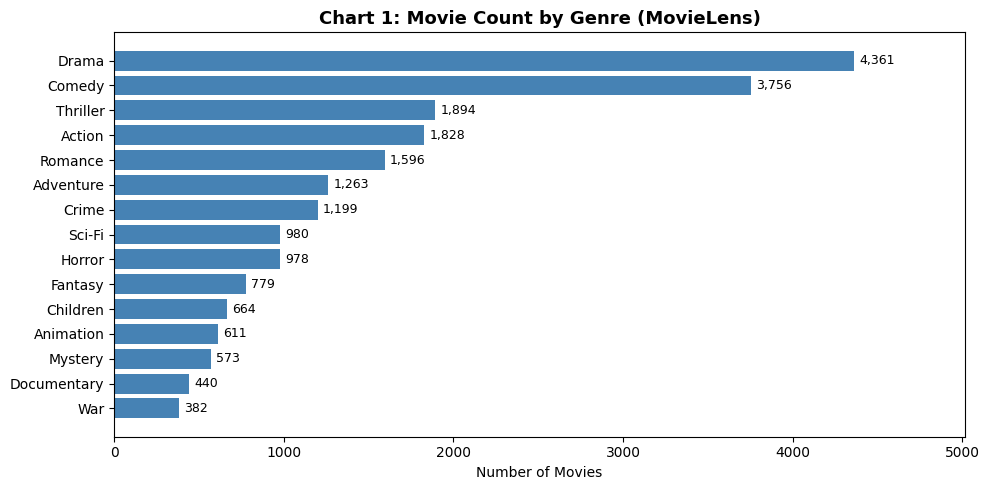

Insight: Drama and Comedy dominate the catalog — recommenders may over-recommend these unless genre weighting is applied.


In [13]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import numpy as np

# ── Chart 1: Genre Distribution ───────────────────────────────────────────────
genre_counts = (
    movies["genres"].str.split("|").explode()
    .value_counts()
    .drop("(no genres listed)", errors="ignore")
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(genre_counts.index[::-1], genre_counts.values[::-1], color="steelblue")
ax.set_xlabel("Number of Movies")
ax.set_title("Chart 1: Movie Count by Genre (MovieLens)", fontsize=13, fontweight="bold")

# Add value labels on bars
for bar, val in zip(bars, genre_counts.values[::-1]):
    ax.text(val + 30, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", fontsize=9)

ax.set_xlim(0, genre_counts.max() * 1.15)
plt.tight_layout()
plt.show()

print("Insight: Drama and Comedy dominate the catalog — recommenders "
      "may over-recommend these unless genre weighting is applied.")


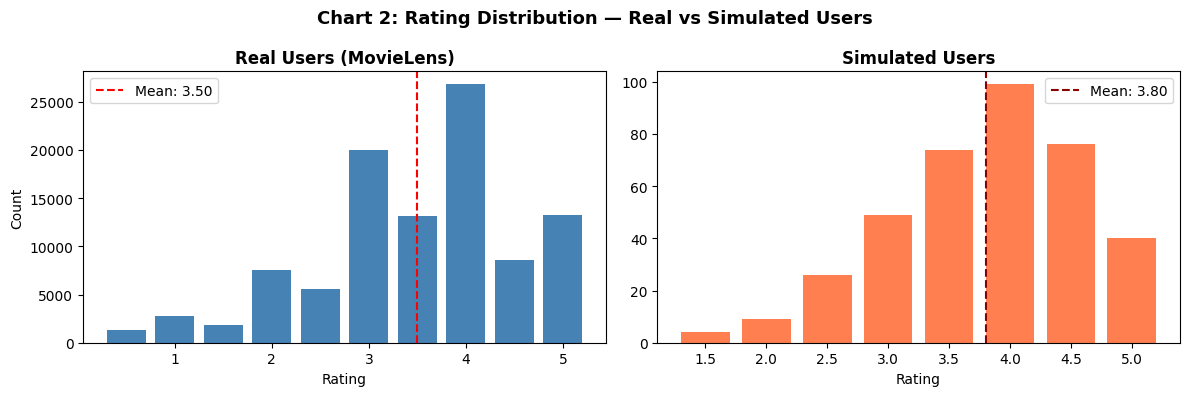

Real users avg rating    : 3.50  — skews positive (people rate what they choose to watch)
Simulated users avg rating: 3.80 — our noise model mirrors this naturally


In [14]:
# ── Chart 2: Rating Distribution ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: real MovieLens users
real_counts = ratings["rating"].value_counts().sort_index()
axes[0].bar(real_counts.index, real_counts.values, width=0.4, color="steelblue")
axes[0].set_title("Real Users (MovieLens)", fontweight="bold")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")
axes[0].axvline(ratings["rating"].mean(), color="red", linestyle="--",
                label=f"Mean: {ratings['rating'].mean():.2f}")
axes[0].legend()

# Right: simulated users
sim_counts = user_ratings_df["rating"].value_counts().sort_index()
axes[1].bar(sim_counts.index, sim_counts.values, width=0.4, color="coral")
axes[1].set_title("Simulated Users", fontweight="bold")
axes[1].set_xlabel("Rating")
axes[1].axvline(user_ratings_df["rating"].mean(), color="darkred", linestyle="--",
                label=f"Mean: {user_ratings_df['rating'].mean():.2f}")
axes[1].legend()

fig.suptitle("Chart 2: Rating Distribution — Real vs Simulated Users",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Real users avg rating    : {ratings['rating'].mean():.2f}  — skews positive (people rate what they choose to watch)")
print(f"Simulated users avg rating: {user_ratings_df['rating'].mean():.2f} — our noise model mirrors this naturally")


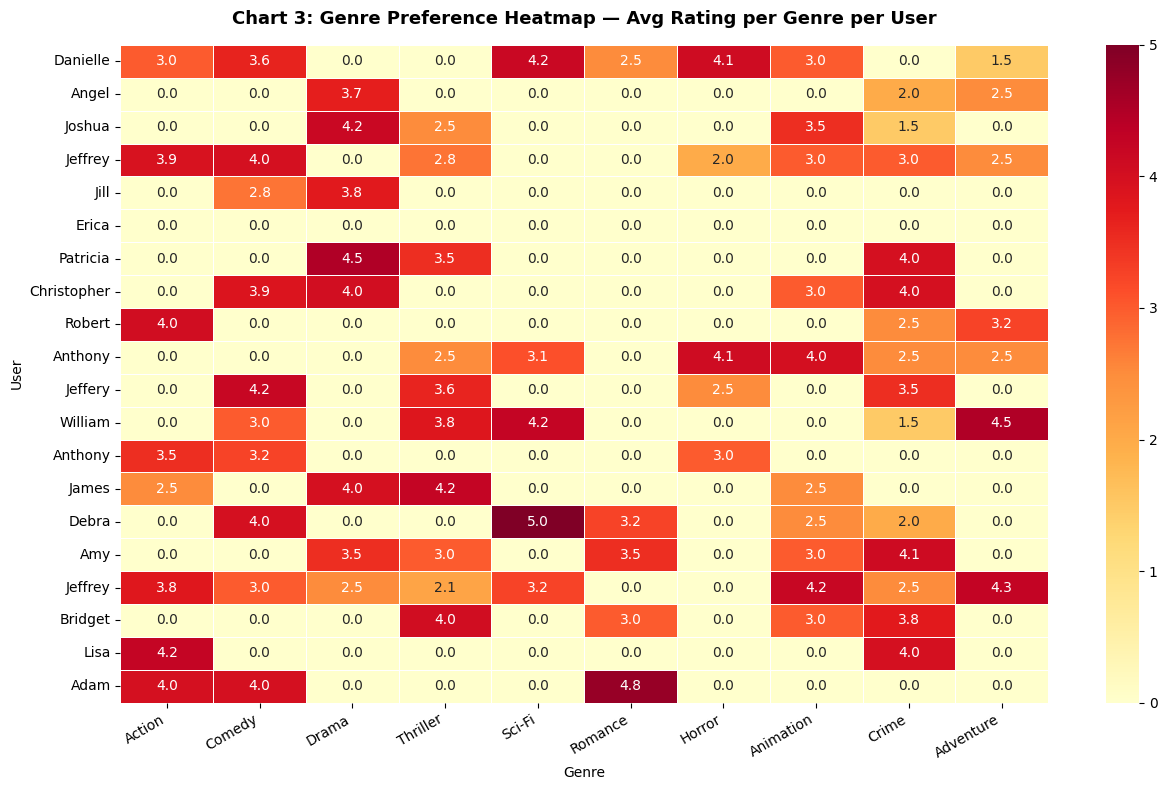

Insight: Empty cells (0) = user never watched that genre.
Dark red cells = strong preference. You can visually spot user taste clusters.


In [15]:
# ── Chart 3: Genre Preference Heatmap (Simulated Users) ──────────────────────
GENRES = ["Action", "Comedy", "Drama", "Thriller", "Sci-Fi",
          "Romance", "Horror", "Animation", "Crime", "Adventure"]

# Build: rows = users, columns = genres, values = avg rating they gave that genre
heatmap_rows = []
for u in user_profiles:
    user_rows = user_ratings_df[user_ratings_df["user_id"] == u["user_id"]]
    row = {"User": u["name"]}
    for g in GENRES:
        genre_rows = user_rows[user_rows["genre_watched"] == g]
        row[g] = round(genre_rows["rating"].mean(), 2) if not genre_rows.empty else 0
    heatmap_rows.append(row)

heatmap_df = pd.DataFrame(heatmap_rows).set_index("User")

fig, ax = plt.subplots(figsize=(13, 8))
sns.heatmap(
    heatmap_df,
    annot=True, fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.4,
    vmin=0, vmax=5,
    ax=ax
)
ax.set_title("Chart 3: Genre Preference Heatmap — Avg Rating per Genre per User",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Genre")
ax.set_ylabel("User")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("Insight: Empty cells (0) = user never watched that genre.")
print("Dark red cells = strong preference. You can visually spot user taste clusters.")


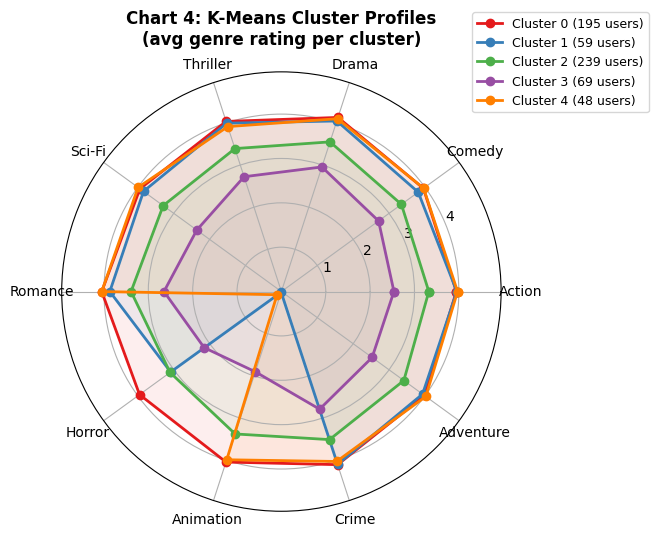

Insight: Each cluster has a distinct genre fingerprint.
Clusters with high Drama/Romance are different taste groups than Action/Thriller ones.
Users assigned to the same cluster get recommendations from the same pool.


In [16]:
# ── Chart 4: Cluster Radar Chart ─────────────────────────────────────────────
from src.recommender import build_genre_vectors
from scipy.cluster.vq import kmeans, vq, whiten

K = 5
genre_matrix = build_genre_vectors(ratings, movies, GENRES)
vectors = genre_matrix.values.astype(float)
whitened = whiten(vectors)
centroids, _ = kmeans(whitened, K)
cluster_labels, _ = vq(whitened, centroids)

# Compute the real (un-whitened) avg genre scores per cluster for plotting
genre_matrix["cluster"] = cluster_labels
cluster_profiles = genre_matrix.groupby("cluster")[GENRES].mean()

# Radar chart: one line per cluster
angles = np.linspace(0, 2 * np.pi, len(GENRES), endpoint=False).tolist()
angles += angles[:1]  # close the circle

colors = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00"]
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for cluster_id, row in cluster_profiles.iterrows():
    values = row.tolist() + row.tolist()[:1]
    n_users = (cluster_labels == cluster_id).sum()
    ax.plot(angles, values, "o-", linewidth=2,
            color=colors[cluster_id],
            label=f"Cluster {cluster_id} ({n_users} users)")
    ax.fill(angles, values, alpha=0.07, color=colors[cluster_id])

ax.set_thetagrids(np.degrees(angles[:-1]), GENRES, fontsize=10)
ax.set_ylim(0, cluster_profiles.values.max() * 1.2)
ax.set_title("Chart 4: K-Means Cluster Profiles\n(avg genre rating per cluster)",
             fontsize=12, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout()
plt.show()

print("Insight: Each cluster has a distinct genre fingerprint.")
print("Clusters with high Drama/Romance are different taste groups than Action/Thriller ones.")
print("Users assigned to the same cluster get recommendations from the same pool.")
